In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from pathlib import Path
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, auc
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Пути
PROJECT_DIR = Path.cwd().parent
DATA_PATH = PROJECT_DIR / "data" / "processed" / "processed_data.csv"
MODEL_DIR = PROJECT_DIR / "models" / "v1"
MODEL_PATH = MODEL_DIR / "cbm.pkl"
THRESHOLD_PATH = MODEL_DIR / "threshold.json"

# Загрузка данных
df = pd.read_csv(DATA_PATH)
print(f"Загружено {df.shape[0]} записей")

# Отделяем X и y
X = df.drop(columns=['churn'])
y = df['churn']

# Загрузка модели и порога
model = joblib.load(MODEL_PATH)
with open(THRESHOLD_PATH, 'r') as f:
    threshold_data = json.load(f)
threshold = threshold_data['threshold']

# Предсказания вероятностей и классов
y_proba = model.predict_proba(X)[:, 1]
y_pred = (y_proba >= threshold).astype(int)

Загружено 9525 записей


In [4]:
# Метрики
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score

print("=== Метрики на полной выборке ===")
print(f"ROC-AUC: {roc_auc_score(y, y_proba):.4f}")
print(f"Порог: {threshold:.4f}")
print(f"Precision: {precision_score(y, y_pred):.4f}")
print(f"Recall: {recall_score(y, y_pred):.4f}")
print(f"F1-score: {f1_score(y, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y, y_pred))

=== Метрики на полной выборке ===
ROC-AUC: 0.8108
Порог: 0.0337
Precision: 0.1427
Recall: 0.9977
F1-score: 0.2497

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.40      0.58      8664
           1       0.14      1.00      0.25       861

    accuracy                           0.46      9525
   macro avg       0.57      0.70      0.41      9525
weighted avg       0.92      0.46      0.55      9525



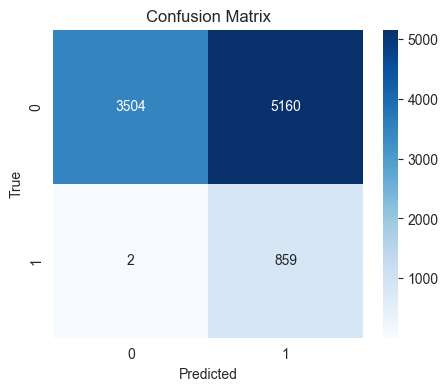

In [5]:
# Confusion Matrix
cm = confusion_matrix(y, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

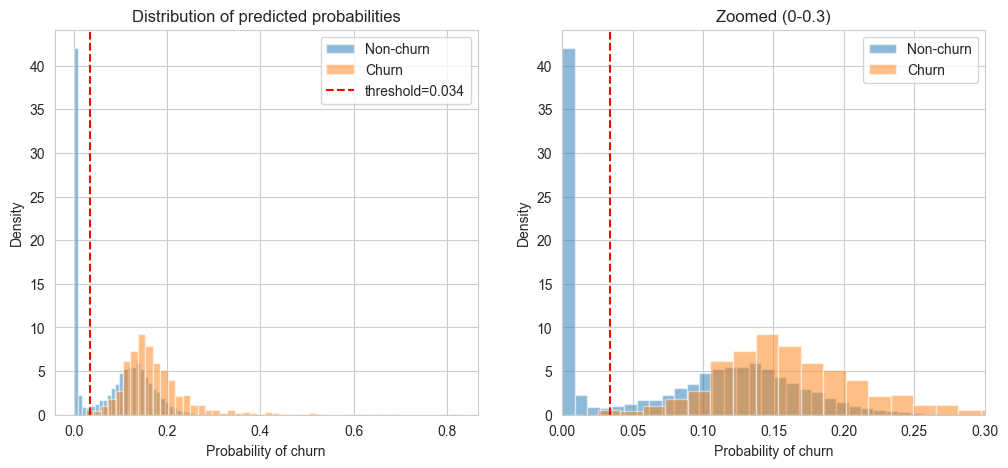

In [6]:
# Распределение вероятностей
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.hist(y_proba[y==0], bins=50, alpha=0.5, label='Non-churn', density=True)
plt.hist(y_proba[y==1], bins=50, alpha=0.5, label='Churn', density=True)
plt.axvline(threshold, color='red', linestyle='--', label=f'threshold={threshold:.3f}')
plt.xlabel('Probability of churn')
plt.ylabel('Density')
plt.legend()
plt.title('Distribution of predicted probabilities')

plt.subplot(1,2,2)
plt.hist(y_proba[y==0], bins=50, alpha=0.5, label='Non-churn', density=True)
plt.hist(y_proba[y==1], bins=50, alpha=0.5, label='Churn', density=True)
plt.axvline(threshold, color='red', linestyle='--')
plt.xlim(0, 0.3)
plt.xlabel('Probability of churn')
plt.ylabel('Density')
plt.legend()
plt.title('Zoomed (0-0.3)')
plt.show()

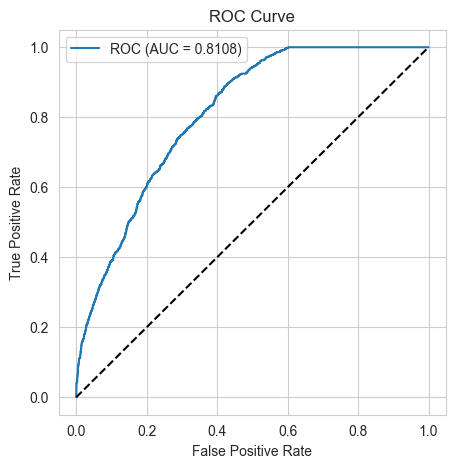

In [7]:
# ROC-кривая
fpr, tpr, _ = roc_curve(y, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

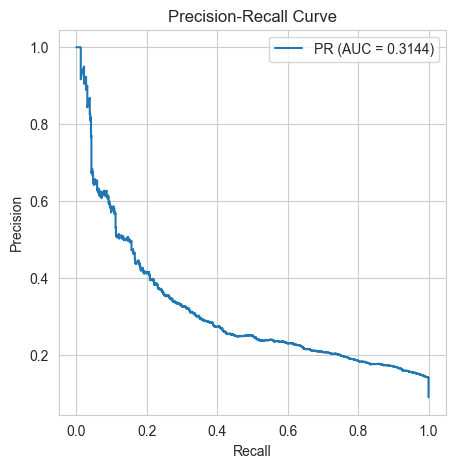

In [8]:
# Precision-Recall кривая
precision, recall, _ = precision_recall_curve(y, y_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(5,5))
plt.plot(recall, precision, label=f'PR (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

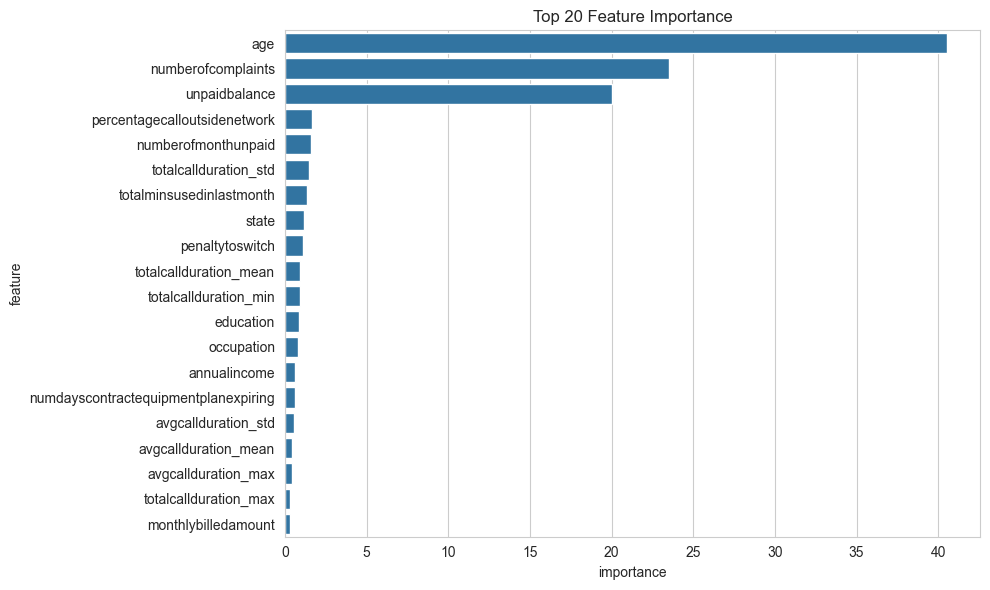

In [9]:
# Важность признаков
feature_importance = model.get_feature_importance()
feature_names = model.feature_names_
imp_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importance})
imp_df = imp_df.sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()

In [10]:
# Анализ ошибок: ложноположительные и ложноотрицательные
df_results = X.copy()
df_results['true'] = y
df_results['pred'] = y_pred
df_results['proba'] = y_proba

fp = df_results[(df_results['true'] == 0) & (df_results['pred'] == 1)]
fn = df_results[(df_results['true'] == 1) & (df_results['pred'] == 0)]

print(f"Ложноположительные (FP): {len(fp)}")
print(f"Ложноотрицательные (FN): {len(fn)}")

Ложноположительные (FP): 5160
Ложноотрицательные (FN): 2


In [12]:
# Выводы
print("\n=== Выводы ===")
print(f"Модель с порогом {threshold:.4f} даёт высокий recall ({recall_score(y, y_pred):.4f}) за счёт низкой precision ({precision_score(y, y_pred):.4f}).")
print(f"Это означает, что мы находим большинство уходящих клиентов, но при этом ошибочно помечаем много лояльных.")
print("Feature importance показывает, что признаки имеют слабую связь с оттоком (важности распределены равномерно).")
print("Это указывает на низкую информативность признаков, возможно, данные сгенерированы искусственно.")


=== Выводы ===
Модель с порогом 0.0337 даёт высокий recall (0.9977) за счёт низкой precision (0.1427).
Это означает, что мы находим большинство уходящих клиентов, но при этом ошибочно помечаем много лояльных.
Feature importance показывает, что признаки имеют слабую связь с оттоком (важности распределены равномерно).
Это указывает на низкую информативность признаков, возможно, данные сгенерированы искусственно.
